<a href="https://colab.research.google.com/github/chenyufei-lianxi/pytorch/blob/main/simple_NeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [149]:
#create a model class that inherits nn.Module
class Model(nn.Module):
  #Input layer(4 features of the flower)-->
  #Hidden layer1(number of neurons)-->
  #H2(n)-->
  #output(3 classes of iris flowers)
  def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
    super().__init__()#instantiate our nn.module
    self.fc1=nn.Linear(in_features,h1)
    self.fc2=nn.Linear(h1,h2)
    self.out=nn.Linear(h2,out_features)

  def forward(self,x):
    x=F.relu(self.fc1(x))
    x=F.relu(self.fc2(x))
    x=self.out(x)

    return x


In [150]:
#Pick a manual seed for randomization
torch.manual_seed(32)
#Create an instance of model
model=Model()

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [152]:
url ='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [153]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [154]:
my_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [155]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [156]:
#Change last column from strings to integers
my_df['species']=my_df['species'].replace('setosa',0.0)
my_df['species']=my_df['species'].replace('versicolor',1.0)
my_df['species']=my_df['species'].replace('virginica',2.0)
my_df

/tmp/ipykernel_10691/3495182954.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species']=my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [157]:
#Train Test Split1 Set X,y
X=my_df.drop('species',axis=1)
y=my_df['species']

In [158]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [159]:
#Convert these to numpy arrays
X=X.values
y=y.values

In [160]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [161]:
from sklearn.model_selection import train_test_split

In [162]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=32)

In [163]:
#Convert X features to float tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)

In [164]:
#Convert y labels to tensors long
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)

In [165]:
#Set the criterion of model to messure the error, how far off the prediction are from the data
criterion=nn.CrossEntropyLoss()
#Choose  Adam Optimizer,lr=learning rate(if error doesn't go down after a bunch of iterations(epochs),lower out learning rate)
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [166]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [167]:
#Train our model
#Epochs?(one run thru all the training data in our network)
epochs=100
losses=[]
for i in range(epochs):
  # Go forwards and get a prediction
  y_pred=model.forward(X_train)#Get predicted results

  #Measure the loss/error, gonna be high at first
  loss=criterion(y_pred,y_train)#predicted values vs the y_train

  #keep track of our losses
  losses.append(loss.detach().numpy())

  #print every 10 epoch
  if i%10==0:
    print(f'Epoch:{i}and loss:{loss}')

  #Do some back propagation: take the error rate of forward propagation and feed it back
  #thru the network the fine the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch:0and loss:1.169895887374878
Epoch:10and loss:0.9578844308853149
Epoch:20and loss:0.7988812923431396
Epoch:30and loss:0.634953498840332
Epoch:40and loss:0.44043001532554626
Epoch:50and loss:0.291716992855072
Epoch:60and loss:0.17829042673110962
Epoch:70and loss:0.11587586998939514
Epoch:80and loss:0.08928147703409195
Epoch:90and loss:0.07743765413761139


Text(0.5, 0, 'Epoch')

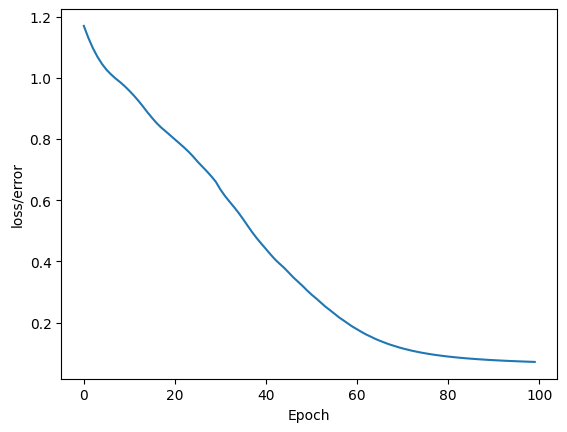

In [168]:
#Graph it our
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [169]:
#Evaluate Model on Test Data Set(validate model on test set)
with torch.no_grad(): #Basically turn off back propogation
  y_eval=model.forward(X_test)#X_test are features from out test set, y_eval will be predictions
  loss=criterion(y_eval,y_test)#find the loss or error

In [170]:
loss

tensor(0.0539)

In [171]:
correct=0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    #Will tell us what type of flower class out network thinks it is
    print(f'{i+1}.){str(y_val)}\t{y_test[i]}\t {y_val.argmax().item()}')

    #Correct or not
    if y_val.argmax().item()==y_test[i]:
      correct+=1

print(f'We got {correct}correct')

1.)tensor([-3.3580,  3.9452,  0.3616])	1	 1
2.)tensor([  7.5862,   1.1113, -11.3861])	0	 0
3.)tensor([  6.6288,   1.5092, -10.4603])	0	 0
4.)tensor([-3.3304,  4.2647,  0.0569])	1	 1
5.)tensor([-7.3705,  2.8135,  5.1481])	2	 2
6.)tensor([-7.3749,  3.9061,  4.2781])	2	 2
7.)tensor([  6.2304,   1.6527, -10.0543])	0	 0
8.)tensor([  6.8783,   1.4056, -10.7016])	0	 0
9.)tensor([-2.6728,  4.3138, -0.6444])	1	 1
10.)tensor([  7.2201,   1.3890, -11.1494])	0	 0
11.)tensor([-3.8269,  4.4110,  0.5165])	1	 1
12.)tensor([-8.6886,  1.9990,  6.9012])	2	 2
13.)tensor([-2.0605,  3.8275, -0.7672])	1	 1
14.)tensor([-1.0676,  4.3809, -2.2975])	1	 1
15.)tensor([-7.5000,  2.6230,  5.3318])	2	 2
16.)tensor([-8.6214,  1.5491,  7.1280])	2	 2
17.)tensor([-3.7724,  3.6503,  0.9422])	1	 1
18.)tensor([-6.7624,  2.7791,  4.5289])	2	 2
19.)tensor([-1.6978,  4.2047, -1.4772])	1	 1
20.)tensor([  7.8104,   1.3824, -11.9435])	0	 0
21.)tensor([  6.9175,   1.5954, -10.9322])	0	 0
22.)tensor([-9.4323,  2.7058,  7.2346])	2	 

In [172]:
new_iris=torch.tensor([4.7,3.2,1.3,0.2])

In [173]:
with torch.no_grad():
  print(model(new_iris))

tensor([  6.9155,   1.2532, -10.6096])
